# Código Clases

## Clase viernes 16 de enero

'''python
from sklearn.submodulo import funcion
'''

### métricas de un problema de clasificación

In [9]:
from sklearn.metrics import accuracy_score, f1_score, precision_score,recall_score
y_true =[1,0,0,0,1,1,0]
y_pred =[0,1,1,0,0,1,0]
y_pred_prob=[0.45, 0.5,0.65,0.5,0.3,0.67,0.1]
accuracy =accuracy_score(y_true,y_pred)
accuracy

precision = precision_score(y_true,y_pred)
precision

sensib= recall_score(y_true,y_pred)

f1 = f1_score(y_true,y_pred)

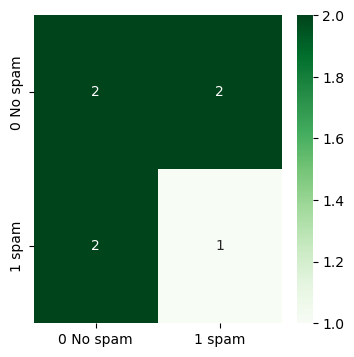

In [6]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true,y_pred)
cm
tn, fp, fn, tp = confusion_matrix(y_true,y_pred).ravel()
import matplotlib.pyplot as plt
import seaborn as sns
clases=['0 No spam','1 spam']
plt.figure(figsize=(4,4))
sns.heatmap(cm,annot=True,cmap='Greens',fmt='g',xticklabels=clases, yticklabels=clases)
plt.show()
plt.close()

In [10]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, ths = roc_curve(y_true, y_pred)
print(f'Tasa de falsos positivos:{fpr}')
print(f'Tasa de verdaderos positivos:{tpr}')
print(f'umbrales de binarización:{ths}')

Tasa de falsos positivos:[0.  0.5 1. ]
Tasa de verdaderos positivos:[0.         0.33333333 1.        ]
umbrales de binarización:[inf  1.  0.]


In [12]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, ths = roc_curve(y_true, y_pred_prob)
print(f'Tasa de falsos positivos:{fpr}')
print(f'Tasa de verdaderos positivos:{tpr}')
print(f'umbrales de binarización:{ths}')

Tasa de falsos positivos:[0.   0.   0.25 0.75 0.75 1.  ]
Tasa de verdaderos positivos:[0.         0.33333333 0.33333333 0.33333333 1.         1.        ]
umbrales de binarización:[ inf 0.67 0.65 0.5  0.3  0.1 ]


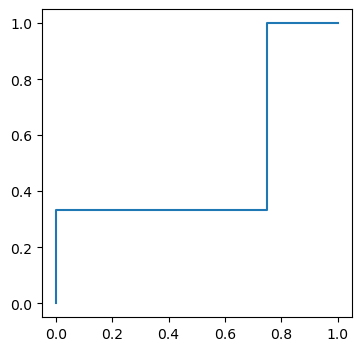

In [16]:
plt.figure(figsize=(4,4))
plt.plot(fpr,tpr,label='Roc_curve')

plt.show()
plt.close()

In [17]:
precision = precision_score(y_true, y_pred_prob)

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [19]:
## OJO: que no se queja por calcular métrica de regresión en un problema de clasificación pero es un ERRROR
from sklearn.metrics import mean_squared_error

mal = mean_squared_error(y_true,y_pred)
mal

0.5714285714285714

### Problema de regresión

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
y_true=np.array([300,450, 607, 983, 321])
y_pred=np.array([340,550, 603, 883, 121])

mse = mean_squared_error(y_true, y_pred)
mae=mean_absolute_error(y_true, y_pred)
r2= r2_score(y_true, y_pred)

In [23]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo

df =fetch_ucirepo(id=45)

#pandas
X = df.data.features
y = df.data.targets

In [6]:
print(X.head())
print(y.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  
   num
0    0
1    2
2    1
3    0
4    0


In [13]:
print(X.shape)
print(X.dtypes)
X.describe()
print(X.corr())
print(y.groupby(y.iloc[:,-1]).size())

(303, 13)
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object
               age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.097542  0.104139  0.284946  0.208950  0.118530   
sex      -0.097542  1.000000  0.010084 -0.064456 -0.199915  0.047862   
cp        0.104139  0.010084  1.000000 -0.036077  0.072319 -0.039975   
trestbps  0.284946 -0.064456 -0.036077  1.000000  0.130120  0.175340   
chol      0.208950 -0.199915  0.072319  0.130120  1.000000  0.009841   
fbs       0.118530  0.047862 -0.039975  0.175340  0.009841  1.000000   
restecg   0.148868  0.021647  0.067505  0.146560  0.171043  0.069564   
thalach  -0.393806 -0.048663 -0.334422 -0.045351 -0.003432 -0.007854   
exang     0.091661  0.146201  0.384060  0.064762  0.061310  0.025665

In [3]:
import numpy as np
y_bin = y.copy()
y_bin[:] = np.where(y>=1,1,0)

In [39]:
variables = X.columns
X.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

In [4]:
import pandas as pd
df = pd.concat([X,y_bin],axis=1) 

df.dropna(inplace=True)

In [22]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [46]:
X = df.drop(df.columns[-1],axis=1)#seleccionar variables explicativas 
y=df.iloc[:, -1]#seleccionar variable objetivo: ojo que esta y ya está binarizada
seed=12345
#1 dividir en train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=seed, test_size=0.2)
# 2. entrenar modelo en train
from sklearn.linear_model import LogisticRegression
#defino mi modelo
modelo = LogisticRegression(random_state=seed,max_iter=10000)
#entreno mi modleo en dato de entrenamiento
modelo.fit(X_train,y_train)
# 3. evaluar modelo en test
y_pred= modelo.predict(X_test) 
y_pred

# 4 evalúo en test
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
accuracy

### calculo accuracy en train para comparar
y_pred_tr = modelo.predict(X_train)
accuracy_tr = accuracy_score(y_train,y_pred_tr)
accuracy_tr

0.8734177215189873

### Punto intermedio que falta. estandarizar variables

In [7]:
X = df.drop(df.columns[-1],axis=1)#seleccionar variables explicativas 
y=df.iloc[:, -1]#seleccionar variable objetivo: ojo que esta y ya está binarizada
seed=12345
#1 dividir en train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=seed, test_size=0.2)

# 2. preparación de los datos: estandarizar variables continuas
from sklearn.preprocessing import StandardScaler
transformacion = StandardScaler()
X_train=transformacion.fit_transform(X_train) #busco la media y devst en train (fit) aplico la media y devst en train (por el transform)
X_test =transformacion.transform(X_test) #con la media y devs buscadas en train, transformo test

# 3. entrenar modelo en train
from sklearn.linear_model import LogisticRegression
#defino mi modelo
modelo = LogisticRegression(random_state=seed,max_iter=10000)
#entreno mi modleo en dato de entrenamiento
modelo.fit(X_train,y_train) # en este puntp, X_train ya ha sido transformada por StandardScaler
# 4. evaluar modelo en test
y_pred= modelo.predict(X_test) 
y_pred

# 5 evalúo en test
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
accuracy

### calculo accuracy en train para comparar
y_pred_tr = modelo.predict(X_train)
accuracy_tr = accuracy_score(y_train,y_pred_tr)
accuracy_tr

0.8776371308016878

## Clase sábado

In [13]:
# predict_proba nos da dos probabilidades (pertenencia clase 0 y pertenencia clase 1) porque estamos
#en un problema binario. Nos interesa la segunda columna, prob clase 1
y_pred = modelo.predict_proba(X_test)[:,1]
y_pred

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred) # no sabe comparar etiqueta con prob

#antes de calcular métricas, tengo qu binarizar, excpto para la curva_roc

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [15]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, ths = roc_curve(y_test, y_pred)

In [19]:
youden_index= tpr-fpr
youden_index
# youden_index nos va a dar el th que maximiza la diferencia entre ambas tasas

array([0.        , 0.03448276, 0.37931034, 0.31479422, 0.52169077,
       0.4894327 , 0.52391546, 0.4916574 , 0.52614016, 0.46162403,
       0.49610679, 0.46384872, 0.53281424, 0.46829811, 0.60622914,
       0.38042269, 0.41490545, 0.38264739, 0.41713014, 0.35261402,
       0.38709677, 0.        ])

In [21]:
best_th = ths[np.argmax(youden_index)]
best_th

0.2042282181271614

In [25]:
# ojo aquí y_pred son prob
y_bin_youden = (y_pred>=best_th).astype(int)
acc_youden = accuracy_score(y_test,y_bin_youden)
acc_youden

0.8

In [27]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
ths = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
results = pd.DataFrame(columns=['th','accuracy','precision','recall','f1'])
for th in ths:
    y_pred_bin = (y_pred>=th).astype(int) #resultado de binarizar con el umbral th los datos test
    accuracy = accuracy_score(y_test, y_pred_bin)
    f1 = f1_score(y_test, y_pred_bin)
    precision = precision_score(y_test, y_pred_bin)
    recall = recall_score(y_test, y_pred_bin)
    new_row = pd.DataFrame({'th': [th],'accuracy':[accuracy],'precision':[precision],
                            'recall':[recall],'f1':[f1]})
    results = pd.concat([results, new_row])

C:\Users\profesorfee\AppData\Local\Temp\ipykernel_1980\289881140.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row])


In [29]:
results

,th,accuracy,precision,recall,f1
0,0.30,0.750000,0.750000,0.724138,0.736842
0,0.35,0.733333,0.740741,0.689655,0.714286
0,0.40,0.733333,0.740741,0.689655,0.714286
0,0.45,0.750000,0.818182,0.620690,0.705882
0,0.50,0.750000,0.850000,0.586207,0.693878
0,0.55,0.750000,0.850000,0.586207,0.693878
0,0.60,0.766667,0.894737,0.586207,0.708333
0,0.65,0.766667,0.894737,0.586207,0.708333
0,0.70,0.766667,0.894737,0.586207,0.708333


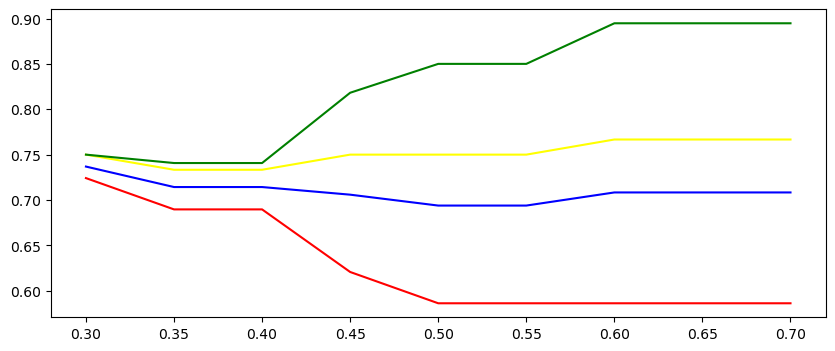

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(results['th'],results['accuracy'],label='accuracy',color='yellow')
plt.plot(results['th'],results['precision'],label='precision',color='green')
plt.plot(results['th'],results['f1'],label='f1',color='blue')
plt.plot(results['th'],results['recall'],label='recall',color='red')
plt.show()
plt.close()

In [35]:
## acceder a los parámetros aprendidos/entrenados en una regresión
print(modelo.coef_) #coeficientes de las variables explicativas
print(modelo.intercept_) #beta0


[[-0.165313    0.60696809  0.48555995  0.3454786   0.29442179 -0.19685384
   0.24356801 -0.47203922  0.38612774  0.51443672  0.27583549  1.168801
   0.79097658]]
[-0.13054953]


In [37]:
dir(modelo)

['C',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_predict_proba_lr',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_validate_data',
 '_validate_params',
 'class_weight',
 'classes_',
 'coef_',
 'decision_function',
 'densify',
 'dual',
 'fit',
 'fit_inter

In [40]:
modelo.n_iter_

array([9])

In [43]:
seed=12345
#1 dividir en train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=seed, test_size=0.2)

# 2. preparación de los datos: estandarizar variables continuas
from sklearn.preprocessing import StandardScaler
transformacion = StandardScaler()
X_train=transformacion.fit_transform(X_train) #busco la media y devst en train (fit) aplico la media y devst en train (por el transform)
X_test =transformacion.transform(X_test) #con la media y devs buscadas en train, transformo test

# 3. entrenar modelo en train
from sklearn.neural_network import MLPClassifier
#defino mi modelo
modelo = MLPClassifier(random_state=seed,max_iter=1000)
#entreno mi modleo en dato de entrenamiento
modelo.fit(X_train,y_train) # en este puntp, X_train ya ha sido transformada por StandardScaler
# 4. evaluar modelo en test
y_pred= modelo.predict(X_test) 
y_pred

# 5 evalúo en test
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
accuracy

### calculo accuracy en train para comparar
y_pred_tr = modelo.predict(X_train)
accuracy_tr = accuracy_score(y_train,y_pred_tr)
accuracy_tr
accuracy #valor en test

0.7833333333333333

In [ ]:
## Ejemplo Saheart

In [77]:
df = pd.read_csv('C:/Users/profesorfee/Documents/Datasets/SAheart.csv')
df.head()

#df.shape
#df.chd.value_counts()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,Si
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,Si
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,No
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,Si
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,Si


In [78]:
df['chd'] = df['chd'].apply(lambda x: 1 if x =='Si' else 0)
df.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


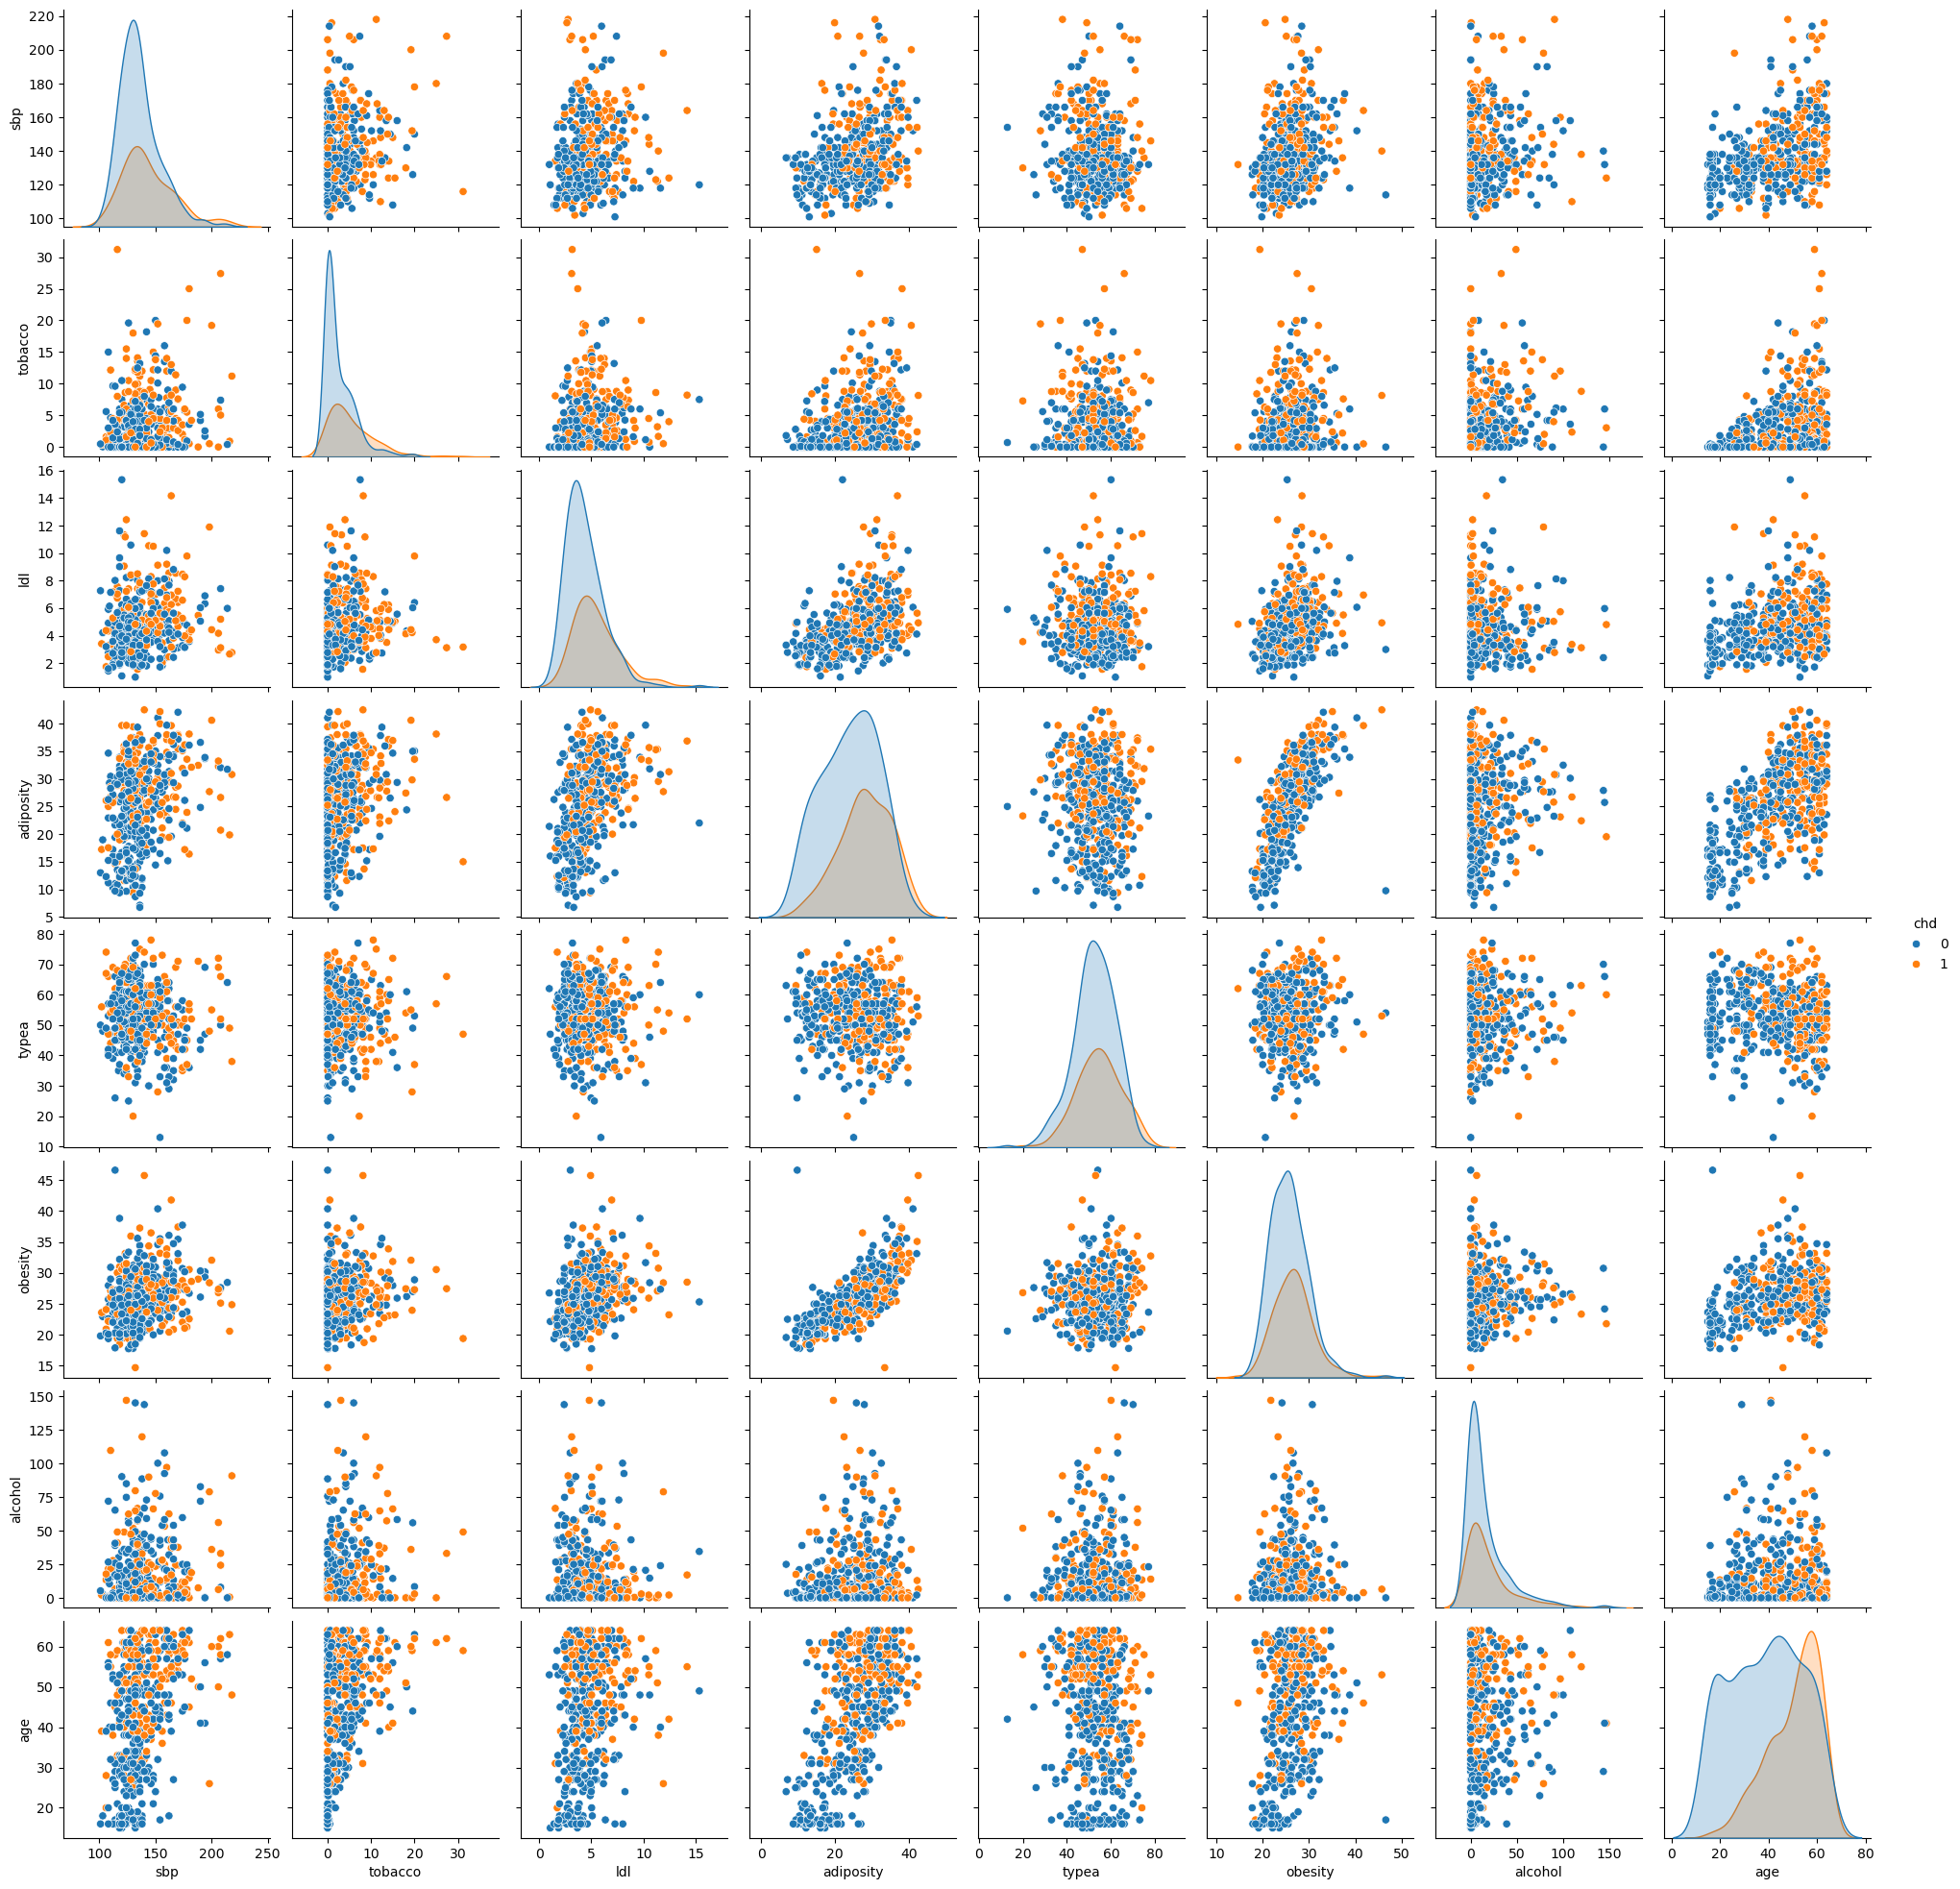

In [62]:
import seaborn as sns
sns.pairplot(df,hue='chd')

In [63]:
df.dtypes

sbp            int64
tobacco      float64
ldl          float64
adiposity    float64
famhist       object
typea          int64
obesity      float64
alcohol      float64
age            int64
chd            int64
dtype: object

In [64]:
df.isnull().sum()

sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64

In [76]:
##forma de obtener dummies con pandas NO HACER EASI, sino con OHE
df[['famhist']] = pd.get_dummies(df[['famhist']],drop_first=True)

In [79]:
df

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1
...,...,...,...,...,...,...,...,...,...,...
457,214,0.40,5.98,31.72,Absent,64,28.45,0.00,58,0
458,182,4.20,4.41,32.10,Absent,52,28.61,18.72,52,1
459,108,3.00,1.59,15.23,Absent,40,20.09,26.64,55,0
460,118,5.40,11.61,30.79,Absent,64,27.35,23.97,40,0


In [86]:
X.shape
X_train.shape

(369, 2)

In [98]:
X=df[['age','tobacco']]
y=df['chd']
seed=13232

# 1 tr/ts
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=0.2)

# 2 Transformación de variables para NN: estandarización+OHE+no missing (esto ya está de antes)
from sklearn.preprocessing import MinMaxScaler
transformador = MinMaxScaler()
X_train = transformador.fit_transform(X_train)
X_test= transformador.transform(X_test)

# 3 Defino el modelo
modelo = MLPClassifier(random_state=seed, hidden_layer_sizes=(4), activation='tanh',max_iter=1000)

# 4. Entreno el modelo en datos de entrenamiento
modelo.fit(X_train, y_train)

# 5. Obtengo predicciones y evalúo en test
y_pred = modelo.predict(X_test)
y_pred

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.73      0.95      0.83        63
           1       0.73      0.27      0.39        30

    accuracy                           0.73        93
   macro avg       0.73      0.61      0.61        93
weighted avg       0.73      0.73      0.69        93



In [99]:
dir(modelo)
modelo.n_iter_

516

In [104]:
### ejemplo con cross_val_score
from sklearn.model_selection import cross_val_score
estimador = MLPClassifier(random_state=seed, hidden_layer_sizes=(4), activation='tanh',max_iter=1000)
## OJO: FALTA ESTANDARIZAR X
cv_scores = cross_val_score(estimador, X, y, cv=4,scoring='accuracy')

cv_scores
np.mean(cv_scores)

0.6687968515742129

### Trabajar con variables categóricas

In [109]:
X=df[['famhist']]
y=df['chd']
seed=13232

# 1 tr/ts
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=0.2)

# 2 Transformación de variables para NN: estandarización+OHE+no missing (esto ya está de antes)
from sklearn.preprocessing import OneHotEncoder
transformador = OneHotEncoder(drop='first')
X_train = transformador.fit_transform(X_train)
X_test= transformador.transform(X_test)

# 3 Defino el modelo
modelo = MLPClassifier(random_state=seed, hidden_layer_sizes=(4), activation='tanh',max_iter=1000)

# 4. Entreno el modelo en datos de entrenamiento
modelo.fit(X_train, y_train)

# 5. Obtengo predicciones y evalúo en test
y_pred = modelo.predict(X_test)
y_pred

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.68      1.00      0.81        63
           1       0.00      0.00      0.00        30

    accuracy                           0.68        93
   macro avg       0.34      0.50      0.40        93
weighted avg       0.46      0.68      0.55        93



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Categóricas y numéricas

In [112]:
X=df[['famhist','age','obesity']] #a las variables continuas hay que hacer una cosa, y a las categóricas otra
y=df['chd']
seed=13232

# 1 tr/ts
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=0.2)

# 2 Transformación de variables para NN: estandarización+OHE+no missing (esto ya está de antes)
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer
transformador = ColumnTransformer([('OHE', OneHotEncoder(drop='first'),['famhist']),
                                  ('MinMax',MinMaxScaler(),['age','obesity'])])
X_train = transformador.fit_transform(X_train)
X_test= transformador.transform(X_test)

# 3 Defino el modelo
modelo = MLPClassifier(random_state=seed, hidden_layer_sizes=(4), activation='tanh',max_iter=1000)

# 4. Entreno el modelo en datos de entrenamiento
modelo.fit(X_train, y_train)

# 5. Obtengo predicciones y evalúo en test
y_pred = modelo.predict(X_test)
y_pred

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.89      0.81        63
           1       0.59      0.33      0.43        30

    accuracy                           0.71        93
   macro avg       0.66      0.61      0.62        93
weighted avg       0.69      0.71      0.68        93



## Problema de regresión

In [118]:
X=df[['famhist','tobacco','obesity','alcohol']] #a las variables continuas hay que hacer una cosa, y a las categóricas otra
y=df['age']
seed=13232

# 1 tr/ts
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=0.2)

# 2 Transformación de variables para NN: estandarización+OHE+no missing (esto ya está de antes)
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer
transformador = ColumnTransformer([('OHE', OneHotEncoder(drop='first'),['famhist']),
                                  ('MinMax',MinMaxScaler(),['tobacco','obesity','alcohol'])])
X_train = transformador.fit_transform(X_train)
X_test= transformador.transform(X_test)

# 3 Defino el modelo
from sklearn.neural_network import MLPRegressor
modelo = MLPRegressor(random_state=seed, hidden_layer_sizes=(4), activation='tanh',max_iter=10000)

# 4. Entreno el modelo en datos de entrenamiento
modelo.fit(X_train, y_train)

# 5. Obtengo predicciones y evalúo en test
y_pred = modelo.predict(X_test)
y_pred

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 =r2_score(y_test, y_pred)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [120]:
print(mse)
print(r2)

111.67206260738286
0.39711966859506387


## Selección de variables en problemas de clasificación

In [138]:
## Selección de variables con selectKBest

X=df[['famhist','age','ldl', 'sbp','typea','obesity']] #a las variables continuas hay que hacer una cosa, y a las categóricas otra
y=df['chd']
seed=13232

# 1 tr/ts
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=0.2)

# 2 Transformación de variables para NN: estandarización+OHE+no missing (esto ya está de antes)
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.compose import ColumnTransformer
transformador = ColumnTransformer([('OHE', OneHotEncoder(drop='first'),['famhist']),
                                  ('StandardScaler',StandardScaler(),['age','ldl', 'sbp','typea','obesity'])])
X_train = transformador.fit_transform(X_train)
X_test= transformador.transform(X_test)

### SELECCIÓN DE VARIABLES: RFE, Selectkbest
from sklearn.feature_selection import RFE,SelectKBest,chi2
selector= RFE(estimator=LogisticRegression(random_state=seed),n_features_to_select=4)
X_train = selector.fit_transform(X_train,y_train) #aquí selector ya sabe quiénes son las 4 variables de X_train más utiles para explicar y_train con LogistRegression
X_test = selector.transform(X_test)

# 3 Defino el modelo
modelo = MLPClassifier(random_state=seed, hidden_layer_sizes=(2), activation='tanh',max_iter=1000)

# 4. Entreno el modelo en datos de entrenamiento
modelo.fit(X_train, y_train)

# 5. Obtengo predicciones y evalúo en test
y_pred = modelo.predict(X_test)
y_pred

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.81      0.78        63
           1       0.54      0.47      0.50        30

    accuracy                           0.70        93
   macro avg       0.65      0.64      0.64        93
weighted avg       0.69      0.70      0.69        93



In [142]:
## Selección de variables con selectKBest

X=df[['famhist','age','ldl', 'sbp','typea','obesity']] #a las variables continuas hay que hacer una cosa, y a las categóricas otra
y=df['chd']
seed=13232

# 1 tr/ts
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=0.2)

# 2 Transformación de variables para NN: estandarización+OHE+no missing (esto ya está de antes)
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.compose import ColumnTransformer
transformador = ColumnTransformer([('OHE', OneHotEncoder(drop='first'),['famhist']),
                                  ('MinMaxScaler',MinMaxScaler(),['age','ldl', 'sbp','typea','obesity'])])
X_train = transformador.fit_transform(X_train)
X_test= transformador.transform(X_test)

### SELECCIÓN DE VARIABLES: RFE, Selectkbest
from sklearn.feature_selection import RFE,SelectKBest,chi2
selector= SelectKBest(chi2,k=3)
X_train = selector.fit_transform(X_train,y_train) #aquí RFE ya sabe quiénes son las 4 variables de X_train más utiles para explicar y_train con LogistRegression
X_test = selector.transform(X_test)

# 3 Defino el modelo
modelo = MLPClassifier(random_state=seed, hidden_layer_sizes=(2), activation='tanh',max_iter=1000)

# 4. Entreno el modelo en datos de entrenamiento
modelo.fit(X_train, y_train)

# 5. Obtengo predicciones y evalúo en test
y_pred = modelo.predict(X_test)
y_pred

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.71      0.98      0.83        63
           1       0.83      0.17      0.28        30

    accuracy                           0.72        93
   macro avg       0.77      0.58      0.55        93
weighted avg       0.75      0.72      0.65        93



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


**OJO**: el criterio chi2 necesita que las variables sean no negativas! así que no puedo usar StandarScaler

## Búsqueda de hiperparamétros en parrilla

In [148]:
## Selección de variables con selectKBest

X=df[['famhist','age','ldl', 'sbp','typea','obesity']] #a las variables continuas hay que hacer una cosa, y a las categóricas otra
y=df['chd']
seed=13232

# 1 tr/ts
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=0.2)

# 2 Transformación de variables para NN: estandarización+OHE+no missing (esto ya está de antes)
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.compose import ColumnTransformer
transformador = ColumnTransformer([('OHE', OneHotEncoder(drop='first'),['famhist']),
                                  ('MinMaxScaler',MinMaxScaler(),['age','ldl', 'sbp','typea','obesity'])])
X_train = transformador.fit_transform(X_train)
X_test= transformador.transform(X_test)

### SELECCIÓN DE VARIABLES: RFE, Selectkbest
from sklearn.feature_selection import RFE,SelectKBest,chi2
selector= SelectKBest(chi2,k=3)
X_train = selector.fit_transform(X_train,y_train) #aquí RFE ya sabe quiénes son las 4 variables de X_train más utiles para explicar y_train con LogistRegression
X_test = selector.transform(X_test)

# 3 Defino el modelo base
algoritmo = MLPClassifier(random_state=seed,max_iter=500)

# 4. Defino la parrilla de hiperparámetros
params={'hidden_layer_sizes':[3,5,7,9],
       'activation':['relu','tanh'],
       'alpha':[0.1,0.01,0.001]}
# 5 Defino las métricas de scoring que quiero calcular
scoring = ['accuracy','recall_macro','f1_macro','precision_macro']
 #6. Defini el GridSearch
from sklearn.model_selection import GridSearchCV
modelo = GridSearchCV(estimator=algoritmo,cv=4, param_grid =params,scoring=scoring,refit='accuracy')

# 4. Entreno el modelo en datos de entrenamiento
modelo.fit(X_train, y_train)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` param

GridSearchCV(cv=4, estimator=MLPClassifier(max_iter=500, random_state=13232),
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.1, 0.01, 0.001],
                         'hidden_layer_sizes': [3, 5, 7, 9]},
             refit='accuracy',
             scoring=['accuracy', 'recall_macro', 'f1_macro',
                      'precision_macro'])

In [150]:
modelo.best_estimator_


MLPClassifier(alpha=0.01, hidden_layer_sizes=7, max_iter=500,
              random_state=13232)

In [154]:
resultados = pd.DataFrame(modelo.cv_results_)
resultados

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_alpha,param_hidden_layer_sizes,params,split0_test_accuracy,split1_test_accuracy,...,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro,split0_test_precision_macro,split1_test_precision_macro,split2_test_precision_macro,split3_test_precision_macro,mean_test_precision_macro,std_test_precision_macro,rank_test_precision_macro
0,0.256114,0.036535,0.006452,0.000537,relu,0.100,3,"{'activation': 'relu', 'alpha': 0.1, 'hidden_l...",0.645161,0.652174,...,0.393090,0.001723,22,0.322581,0.326087,0.326087,0.320652,0.323852,0.002337,22
1,0.242092,0.002758,0.006170,0.000697,relu,0.100,5,"{'activation': 'relu', 'alpha': 0.1, 'hidden_l...",0.698925,0.728261,...,0.675102,0.052963,15,0.670635,0.700597,0.820833,0.671954,0.716005,0.061695,15
2,0.195683,0.017336,0.004668,0.000500,relu,0.100,7,"{'activation': 'relu', 'alpha': 0.1, 'hidden_l...",0.709677,0.717391,...,0.685962,0.034473,12,0.684379,0.687097,0.811464,0.695652,0.719648,0.053173,12
3,0.203047,0.014591,0.005096,0.000241,relu,0.100,9,"{'activation': 'relu', 'alpha': 0.1, 'hidden_l...",0.709677,0.717391,...,0.690394,0.031298,3,0.682065,0.686384,0.811464,0.708333,0.722062,0.052568,11
4,0.238604,0.003699,0.006066,0.001006,relu,0.010,3,"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",0.645161,0.652174,...,0.393090,0.001723,22,0.322581,0.326087,0.326087,0.320652,0.323852,0.002337,22
5,0.239247,0.003436,0.005826,0.000414,relu,0.010,5,"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",0.709677,0.728261,...,0.679130,0.043002,13,0.688014,0.700597,0.799128,0.686111,0.718462,0.046904,13
6,0.211937,0.026607,0.005176,0.000906,relu,0.010,7,"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",0.720430,0.717391,...,0.694049,0.028540,1,0.697516,0.687097,0.811464,0.708333,0.726102,0.049852,1
7,0.204039,0.020508,0.005033,0.000698,relu,0.010,9,"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",0.720430,0.706522,...,0.690341,0.030530,4,0.697516,0.674056,0.811464,0.708333,0.722842,0.052645,9
8,0.236921,0.002801,0.005854,0.000719,relu,0.001,3,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.645161,0.652174,...,0.393090,0.001723,22,0.322581,0.326087,0.326087,0.320652,0.323852,0.002337,22
9,0.243246,0.003675,0.006231,0.000786,relu,0.001,5,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.709677,0.728261,...,0.679130,0.043002,13,0.688014,0.700597,0.799128,0.686111,0.718462,0.046904,13


In [158]:
resultados = resultados.sort_values(by='mean__test_accuracy',ascending=False)
resultados

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_alpha,param_hidden_layer_sizes,params,split0_test_accuracy,split1_test_accuracy,...,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro,split0_test_precision_macro,split1_test_precision_macro,split2_test_precision_macro,split3_test_precision_macro,mean_test_precision_macro,std_test_precision_macro,rank_test_precision_macro
10,0.197045,0.014752,0.005269,0.000573,relu,0.001,7,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.720430,0.717391,...,0.694049,0.028540,1,0.697516,0.687097,0.811464,0.708333,0.726102,0.049852,1
6,0.211937,0.026607,0.005176,0.000906,relu,0.010,7,"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",0.720430,0.717391,...,0.694049,0.028540,1,0.697516,0.687097,0.811464,0.708333,0.726102,0.049852,1
15,0.180264,0.008900,0.004958,0.000510,tanh,0.100,9,"{'activation': 'tanh', 'alpha': 0.1, 'hidden_l...",0.709677,0.728261,...,0.689591,0.034813,9,0.684379,0.699894,0.811464,0.695652,0.722847,0.051476,6
23,0.181597,0.007561,0.005430,0.000294,tanh,0.001,9,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",0.709677,0.728261,...,0.689591,0.034813,9,0.684379,0.699894,0.811464,0.695652,0.722847,0.051476,6
19,0.217173,0.045265,0.005390,0.000406,tanh,0.010,9,"{'activation': 'tanh', 'alpha': 0.01, 'hidden_...",0.709677,0.728261,...,0.689591,0.034813,9,0.684379,0.699894,0.811464,0.695652,0.722847,0.051476,6
3,0.203047,0.014591,0.005096,0.000241,relu,0.100,9,"{'activation': 'relu', 'alpha': 0.1, 'hidden_l...",0.709677,0.717391,...,0.690394,0.031298,3,0.682065,0.686384,0.811464,0.708333,0.722062,0.052568,11
7,0.204039,0.020508,0.005033,0.000698,relu,0.010,9,"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",0.720430,0.706522,...,0.690341,0.030530,4,0.697516,0.674056,0.811464,0.708333,0.722842,0.052645,9
11,0.201901,0.018988,0.005968,0.000829,relu,0.001,9,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.720430,0.706522,...,0.690341,0.030530,4,0.697516,0.674056,0.811464,0.708333,0.722842,0.052645,9
22,0.189441,0.018080,0.005207,0.000012,tanh,0.001,7,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",0.720430,0.717391,...,0.689818,0.021447,6,0.697516,0.687097,0.801802,0.708333,0.723687,0.045720,3
14,0.178516,0.011469,0.005070,0.000540,tanh,0.100,7,"{'activation': 'tanh', 'alpha': 0.1, 'hidden_l...",0.720430,0.717391,...,0.689818,0.021447,6,0.697516,0.687097,0.801802,0.708333,0.723687,0.045720,3


In [161]:
ac0 = resultados[['split0_test_accuracy','split1_test_accuracy','split2_test_accuracy','split3_test_accuracy']].iloc[0]
ac1 = resultados[['split0_test_accuracy','split1_test_accuracy','split2_test_accuracy','split3_test_accuracy']].iloc[1]
ac2 = resultados[['split0_test_accuracy','split1_test_accuracy','split2_test_accuracy','split3_test_accuracy']].iloc[2]
ac3 = resultados[['split0_test_accuracy','split1_test_accuracy','split2_test_accuracy','split3_test_accuracy']].iloc[3]

C:\Users\profesorfee\AppData\Local\Temp\ipykernel_1980\1848027229.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ac0.values, ac1.values, ac2.values, ac3.values],labels=['MLP0','MLP1','MLP2','MLP3'])


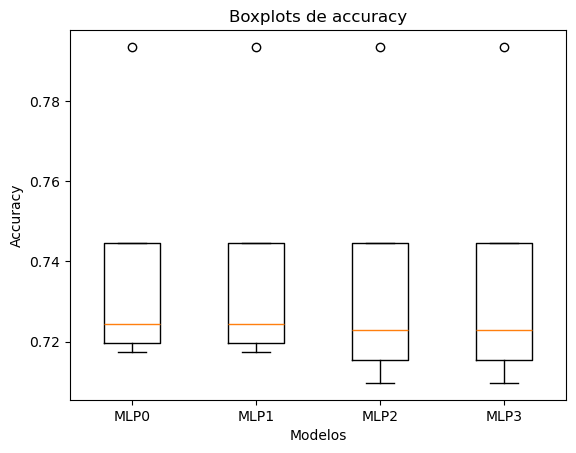

In [163]:
plt.boxplot([ac0.values, ac1.values, ac2.values, ac3.values],labels=['MLP0','MLP1','MLP2','MLP3'])
plt.title('Boxplots de accuracy')
plt.xlabel('Modelos')
plt.ylabel('Accuracy')
plt.show()

## Elijo como buen modelo el que tiene 7 nodos en capa oculta, usa RELU y veo que paece que alpha no afecta demasiado
Tengo que profundizar en la búsqueda paramétrica: por ejemplo, probando con modelos intermedios

In [165]:
## Selección de variables con selectKBest

X=df[['famhist','age','ldl', 'sbp','typea','obesity']] #a las variables continuas hay que hacer una cosa, y a las categóricas otra
y=df['chd']
seed=13232

# 1 tr/ts
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=0.2)

# 2 Transformación de variables para NN: estandarización+OHE+no missing (esto ya está de antes)
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.compose import ColumnTransformer
transformador = ColumnTransformer([('OHE', OneHotEncoder(drop='first'),['famhist']),
                                  ('MinMaxScaler',MinMaxScaler(),['age','ldl', 'sbp','typea','obesity'])])
X_train = transformador.fit_transform(X_train)
X_test= transformador.transform(X_test)

### SELECCIÓN DE VARIABLES: RFE, Selectkbest
from sklearn.feature_selection import RFE,SelectKBest,chi2
selector= SelectKBest(chi2,k=3)
X_train = selector.fit_transform(X_train,y_train) #aquí RFE ya sabe quiénes son las 4 variables de X_train más utiles para explicar y_train con LogistRegression
X_test = selector.transform(X_test)

# 3 Defino el modelo base
algoritmo = MLPClassifier(random_state=seed,max_iter=1000, alpha=0.001)

# 4. Defino la parrilla de hiperparámetros
params={'hidden_layer_sizes':[6,7,8],
       'activation':['relu','tanh']}
# 5 Defino las métricas de scoring que quiero calcular
scoring = ['accuracy','recall_macro','f1_macro','precision_macro']
 #6. Defini el GridSearch
from sklearn.model_selection import GridSearchCV
modelo = GridSearchCV(estimator=algoritmo,cv=4, param_grid =params,scoring=scoring,refit='accuracy')

# 4. Entreno el modelo en datos de entrenamiento
modelo.fit(X_train, y_train)


GridSearchCV(cv=4,
             estimator=MLPClassifier(alpha=0.001, max_iter=1000,
                                     random_state=13232),
             param_grid={'activation': ['relu', 'tanh'],
                         'hidden_layer_sizes': [6, 7, 8]},
             refit='accuracy',
             scoring=['accuracy', 'recall_macro', 'f1_macro',
                      'precision_macro'])

In [167]:
resultados = pd.DataFrame(modelo.cv_results_)
resultados

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_hidden_layer_sizes,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,...,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro,split0_test_precision_macro,split1_test_precision_macro,split2_test_precision_macro,split3_test_precision_macro,mean_test_precision_macro,std_test_precision_macro,rank_test_precision_macro
0,0.370967,0.007909,0.004959,0.000570,relu,6,"{'activation': 'relu', 'hidden_layer_sizes': 6}",0.709677,0.728261,0.793478,...,0.681903,0.037462,5,0.688014,0.700597,0.811464,0.699531,0.724901,0.050220,3
1,0.197075,0.014565,0.005180,0.000689,relu,7,"{'activation': 'relu', 'hidden_layer_sizes': 7}",0.720430,0.717391,0.793478,...,0.694049,0.028540,1,0.697516,0.687097,0.811464,0.708333,0.726102,0.049852,1
2,0.268604,0.021728,0.005224,0.000160,relu,8,"{'activation': 'relu', 'hidden_layer_sizes': 8}",0.698925,0.706522,0.793478,...,0.677592,0.038185,6,0.667647,0.674056,0.811464,0.682468,0.708909,0.059443,6
3,0.291807,0.008225,0.004983,0.000204,tanh,6,"{'activation': 'tanh', 'hidden_layer_sizes': 6}",0.709677,0.728261,0.782609,...,0.688149,0.026420,4,0.684379,0.699234,0.801802,0.708333,0.723437,0.046045,5
4,0.187849,0.017986,0.005697,0.000458,tanh,7,"{'activation': 'tanh', 'hidden_layer_sizes': 7}",0.720430,0.717391,0.782609,...,0.689818,0.021447,3,0.697516,0.687097,0.801802,0.708333,0.723687,0.045720,4
5,0.280875,0.009662,0.005275,0.000210,tanh,8,"{'activation': 'tanh', 'hidden_layer_sizes': 8}",0.698925,0.728261,0.804348,...,0.690676,0.044712,2,0.670635,0.699234,0.820833,0.712338,0.725760,0.056924,2


In [170]:
resultados = resultados.sort_values(by='mean_test_accuracy',ascending=False)
resultados

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_hidden_layer_sizes,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,...,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro,split0_test_precision_macro,split1_test_precision_macro,split2_test_precision_macro,split3_test_precision_macro,mean_test_precision_macro,std_test_precision_macro,rank_test_precision_macro
5,0.280875,0.009662,0.005275,0.000210,tanh,8,"{'activation': 'tanh', 'hidden_layer_sizes': 8}",0.698925,0.728261,0.804348,...,0.690676,0.044712,2,0.670635,0.699234,0.820833,0.712338,0.725760,0.056924,2
1,0.197075,0.014565,0.005180,0.000689,relu,7,"{'activation': 'relu', 'hidden_layer_sizes': 7}",0.720430,0.717391,0.793478,...,0.694049,0.028540,1,0.697516,0.687097,0.811464,0.708333,0.726102,0.049852,1
0,0.370967,0.007909,0.004959,0.000570,relu,6,"{'activation': 'relu', 'hidden_layer_sizes': 6}",0.709677,0.728261,0.793478,...,0.681903,0.037462,5,0.688014,0.700597,0.811464,0.699531,0.724901,0.050220,3
3,0.291807,0.008225,0.004983,0.000204,tanh,6,"{'activation': 'tanh', 'hidden_layer_sizes': 6}",0.709677,0.728261,0.782609,...,0.688149,0.026420,4,0.684379,0.699234,0.801802,0.708333,0.723437,0.046045,5
4,0.187849,0.017986,0.005697,0.000458,tanh,7,"{'activation': 'tanh', 'hidden_layer_sizes': 7}",0.720430,0.717391,0.782609,...,0.689818,0.021447,3,0.697516,0.687097,0.801802,0.708333,0.723687,0.045720,4
2,0.268604,0.021728,0.005224,0.000160,relu,8,"{'activation': 'relu', 'hidden_layer_sizes': 8}",0.698925,0.706522,0.793478,...,0.677592,0.038185,6,0.667647,0.674056,0.811464,0.682468,0.708909,0.059443,6


In [173]:
ac0 = resultados[['split0_test_accuracy','split1_test_accuracy','split2_test_accuracy','split3_test_accuracy']].iloc[0]
ac1 = resultados[['split0_test_accuracy','split1_test_accuracy','split2_test_accuracy','split3_test_accuracy']].iloc[1]
ac2 = resultados[['split0_test_accuracy','split1_test_accuracy','split2_test_accuracy','split3_test_accuracy']].iloc[2]
ac3 = resultados[['split0_test_accuracy','split1_test_accuracy','split2_test_accuracy','split3_test_accuracy']].iloc[3]
ac4 = resultados[['split0_test_accuracy','split1_test_accuracy','split2_test_accuracy','split3_test_accuracy']].iloc[4]

C:\Users\profesorfee\AppData\Local\Temp\ipykernel_1980\2571394921.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ac0.values, ac1.values, ac2.values, ac3.values, ac4.values],labels=['MLP0','MLP1','MLP2','MLP3','MLP4'])


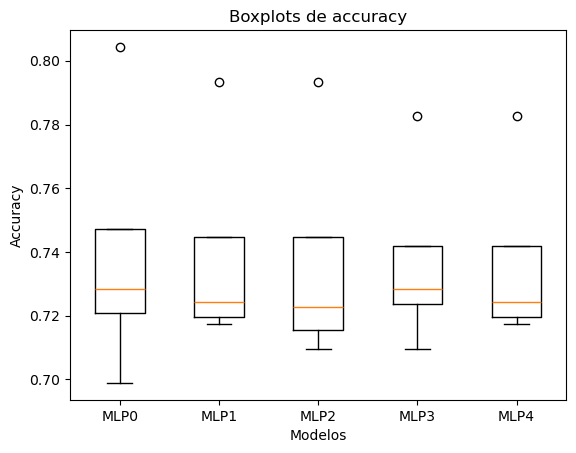

In [176]:
plt.boxplot([ac0.values, ac1.values, ac2.values, ac3.values, ac4.values],labels=['MLP0','MLP1','MLP2','MLP3','MLP4'])
plt.title('Boxplots de accuracy')
plt.xlabel('Modelos')
plt.ylabel('Accuracy')
plt.show()

## FIN DEL PROCESO: tengo que volver a entrenar y validar en datos de tr/ts para poder obtener un modleo concreto

In [187]:
# Selección de variables con selectKBest

X=df[['famhist','age','ldl', 'sbp','typea','obesity']] #a las variables continuas hay que hacer una cosa, y a las categóricas otra
y=df['chd']
seed=13232

# 1 tr/ts
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=0.2)

# 2 Transformación de variables para NN: estandarización+OHE+no missing (esto ya está de antes)
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.compose import ColumnTransformer
transformador = ColumnTransformer([('OHE', OneHotEncoder(drop='first'),['famhist']),
                                  ('MinMaxScaler',MinMaxScaler(),['age','ldl', 'sbp','typea','obesity'])])
X_train = transformador.fit_transform(X_train)
X_test= transformador.transform(X_test)

### SELECCIÓN DE VARIABLES: RFE, Selectkbest
from sklearn.feature_selection import RFE,SelectKBest,chi2
selector= SelectKBest(chi2,k=3)
X_train = selector.fit_transform(X_train,y_train) #aquí RFE ya sabe quiénes son las 4 variables de X_train más utiles para explicar y_train con LogistRegression
X_test = selector.transform(X_test)

ganador = MLPClassifier(random_state=seed,hidden_layer_sizes=(6), activation='tanh',alpha=0.001,max_iter=1000)
ganador.fit(X_train,y_train)
y_pred=ganador.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred)
accuracy_test
from sklearn.metrics import confusion_matrix
cm =confusion_matrix(y_test, y_pred)
cm

array([[54,  9],
       [15, 15]], dtype=int64)

In [188]:
y_pred_prob= ganador.predict_proba(X_test)

## representación de métricas, a ver si consigo mejorar accuracy con punto de corte para binarizaicón
## otra vez confisionMatrix, a ver si mejora con el th